In [1]:
import os
os.chdir("..")
from src.data.puzzle_dataset import PuzzleDataset
from src.models.gridmlp import GridMLP
from src.training.nng_supervised import NNGSupervisedTrainer
from src.data.criterion.categorical_abstain import AbstainLoss
from torch.utils.data import DataLoader, random_split
from notebooks.dataset_construction.parquet_dataset import ParquetReader
import matplotlib.pyplot as plt
import numpy as np
import torch
os.environ["DATA_DIR"] = "../data/"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
os.chdir("./notebooks")


Using device: cuda


In [57]:
depth = 32
def make_dataset(dataset_path, target_shape, batch_size=400):
    pq = ParquetReader(dataset_path, target_shape=target_shape)
    train_loader, test_loader, train_dataset, test_dataset = pq.create_dataloaders(batch_size=batch_size, flat=True)

    return train_loader, test_loader, train_dataset, test_dataset, pq


def train(train_loader, test_loader, criterion, input_shape, target_shape, num_epochs=10, trainer_class=NNGSupervisedTrainer):
    model = GridMLP(input_size=input_shape, hidden_size=128, output_size=target_shape, num_layers=depth, dropout=0.05).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    trainer = trainer_class(model, train_loader, test_loader, criterion, optimizer, device, epochs=num_epochs, print_every=10)
    trainer.train()
    return model, train_loader, test_loader

In [55]:
train_loader, test_loader, train_dataset, test_dataset, pq = make_dataset(dataset_path="../data/raw/nng_5x5_small.parquet", target_shape=(3, 5, 5), batch_size=10000)

In [59]:
mlp_model, train_loader, test_loader = train(
    train_loader, test_loader, AbstainLoss(abstain_penalty=0.7), 30, 75, num_epochs=201)

Starting training...
Epoch 00: Train Loss=0.7915, Train Acc=0.0000 | Test Loss=0.7924, Test Acc=0.0000
Epoch 10: Train Loss=0.3636, Train Acc=0.0115 | Test Loss=0.3638, Test Acc=0.0111
Epoch 20: Train Loss=0.2861, Train Acc=0.0529 | Test Loss=0.2879, Test Acc=0.0507
Epoch 30: Train Loss=0.2173, Train Acc=0.1401 | Test Loss=0.2213, Test Acc=0.1313
Epoch 40: Train Loss=0.1725, Train Acc=0.2497 | Test Loss=0.1793, Test Acc=0.2270
Epoch 50: Train Loss=0.1410, Train Acc=0.3525 | Test Loss=0.1506, Test Acc=0.3161
Epoch 60: Train Loss=0.1191, Train Acc=0.4323 | Test Loss=0.1312, Test Acc=0.3829
Epoch 70: Train Loss=0.1001, Train Acc=0.5204 | Test Loss=0.1153, Test Acc=0.4531
Epoch 80: Train Loss=0.0838, Train Acc=0.5873 | Test Loss=0.1023, Test Acc=0.5093
Epoch 90: Train Loss=0.0699, Train Acc=0.6561 | Test Loss=0.0920, Test Acc=0.5625
Epoch 100: Train Loss=0.0606, Train Acc=0.6976 | Test Loss=0.0856, Test Acc=0.5921
Epoch 110: Train Loss=0.0489, Train Acc=0.7610 | Test Loss=0.0770, Test Acc=

In [5]:
def display_grid(ax, grid, clues=None, title='', mode='blended'):
    if grid.ndim == 3:
        _, H, W = grid.shape
    else:
        H, W = grid.shape

    if mode in ('blended', 'normalised'):
        base_colours = torch.tensor(
            [[1.0, 1.0, 1.0], [0.0, 0.0, 0.0], [0.0, 0.0, 1.0]],
            device=grid.device
        )

        if mode == 'blended':
            weights = torch.softmax(grid, dim=0)
        else:
            weights = grid / grid.sum(dim=0, keepdim=True)

        weights = weights.permute(1, 2, 0)
        img = (weights.reshape(-1, 3) @ base_colours).reshape(H, W, 3)
        img = img.detach().cpu().numpy()

    elif mode == 'rounded':
        img = (grid[0] < grid[1]).cpu().numpy()

    elif mode == 'raw':
        img = grid.detach().cpu().numpy()
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.squeeze(0)

    else:
        raise ValueError(f"Unknown mode: '{mode}'. Expected one of: blended, normalised, rounded, raw")

    # Render image
    ax.imshow(img, cmap='gray_r', interpolation='nearest')
    ax.set_xlim(-0.5, W - 0.5)
    ax.set_ylim(H - 0.5, -0.5)

    # Draw grid lines
    for i in range(H + 1):
        ax.axhline(i - 0.5, color='black', linewidth=1, clip_on=False)
    for j in range(W + 1):
        ax.axvline(j - 0.5, color='black', linewidth=1, clip_on=False)

    ax.axis('off')

    # Add clues
    if clues is not None:
        for i, row_clue in enumerate(clues[0]):
            clue_str = ",".join(str(int(x)) for x in row_clue if x > 0) or "0"
            ax.text(-0.6, i, clue_str, va='center', ha='right', fontsize=12)
        for j, col_clue in enumerate(clues[1]):
            clue_str = ",".join(str(int(x)) for x in col_clue if x > 0) or "0"
            ax.text(j, -0.6, clue_str, va='bottom', ha='center', fontsize=12)

    ax.set_title(title, fontsize=14)


def display_figure_grid(grids, width=None, clues=None, titles=None, figsize=(15, 15), mode='blended'):
    num_grids = len(grids)
    grid_width  = width if width is not None else int(np.ceil(np.sqrt(num_grids)))
    grid_height = int(np.ceil(num_grids / grid_width))
    _, axes = plt.subplots(grid_height, grid_width, figsize=figsize, squeeze=False)
    for i in range(num_grids):
        row = i // grid_width
        col = i % grid_width
        display_grid(
            axes[row, col],
            grids[i],
            title=titles[i] if titles is not None else '',
            clues=clues,
            mode=mode
        )
    total_cells = grid_height * grid_width
    for i in range(num_grids, total_cells):
        row = i // grid_width
        col = i % grid_width
        axes[row, col].axis('off')
        axes[row, col].set_facecolor('none')
    plt.tight_layout()
    plt.show()



In [6]:
def add_uncertainty(num):
    p_0 = 1 - num
    p_1 = num
    p_abstain = 1 - abs(num - 0.5)*2
    return torch.tensor([p_0, p_1, p_abstain], dtype=torch.float32)

def intermediate_with_uncertainty(intermediate_solutions):
    output = []
    for sol in intermediate_solutions:
        stacked = torch.stack([add_uncertainty(num) for num in sol.flatten()], dim=0)
        transposed = stacked.transpose(0, 1)
        reshaped = transposed.reshape(3, sol.shape[0], sol.shape[1])
        output.append(reshaped)
    return output

Correct solution:


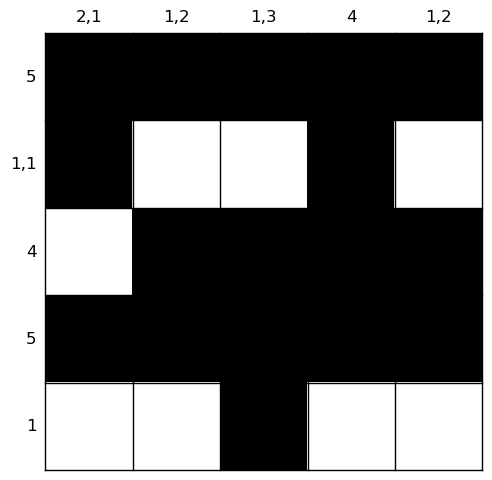

Model predictions:


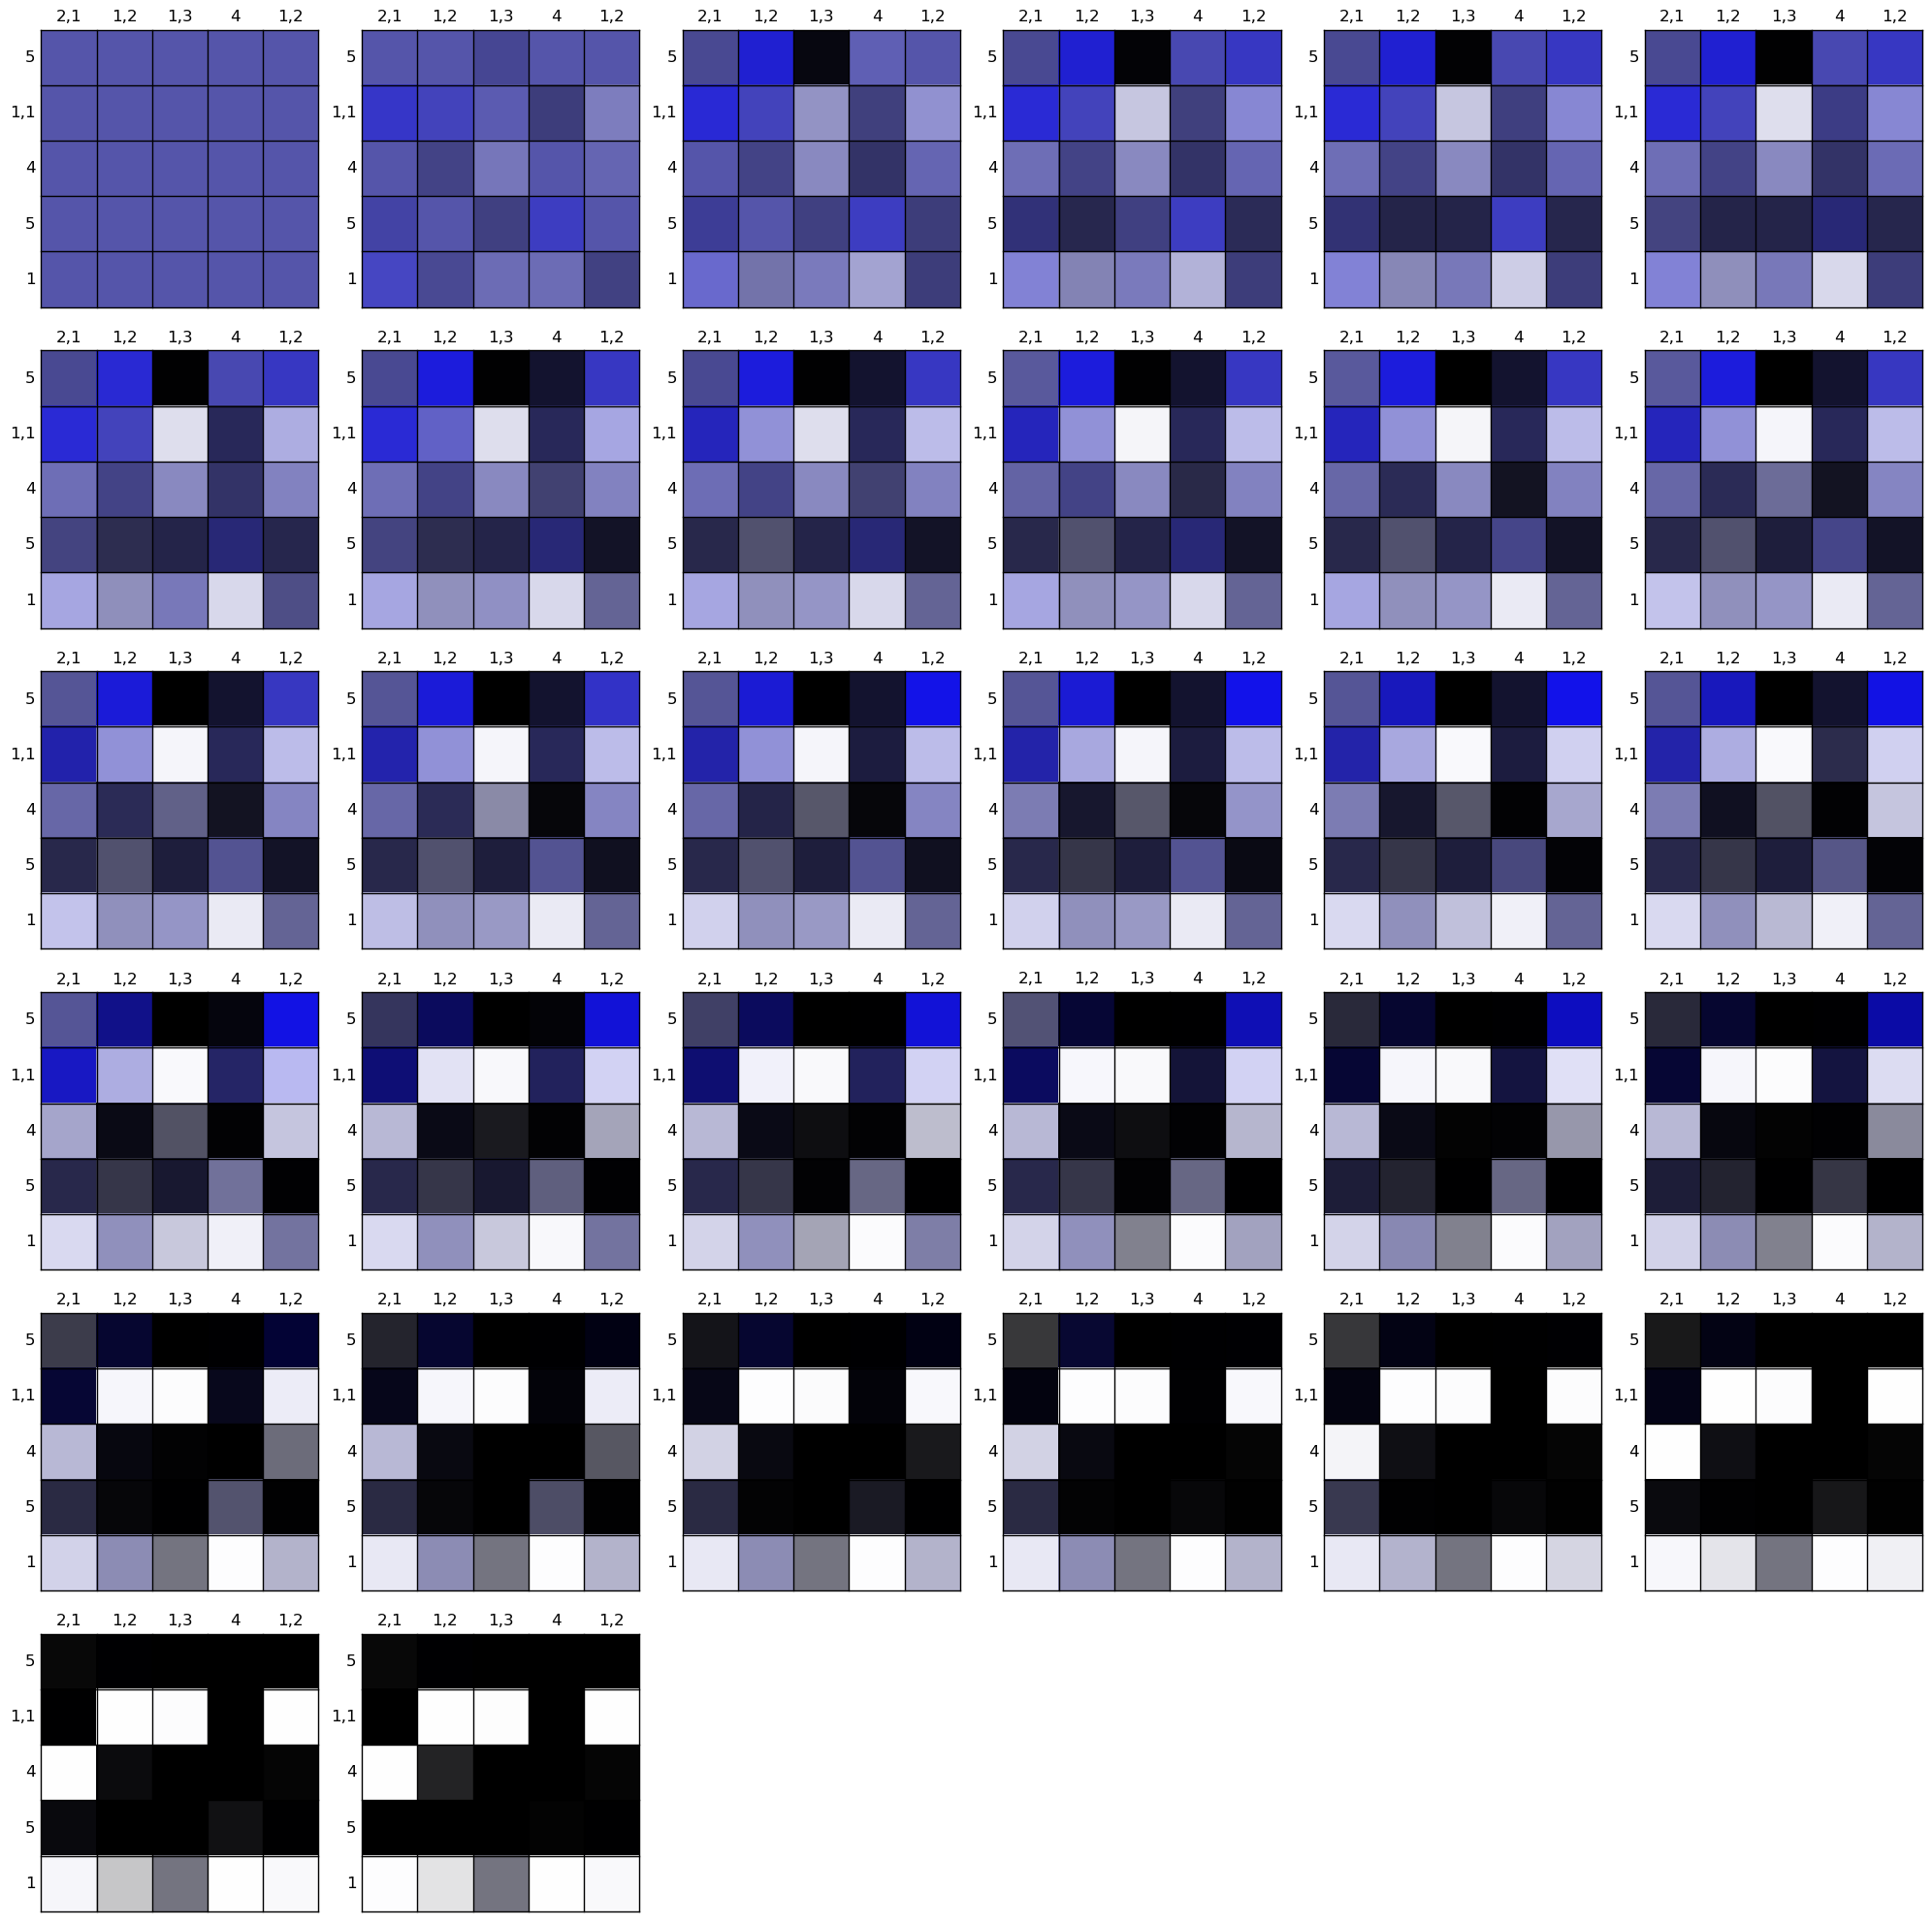

Intermediate with Uncertainty:


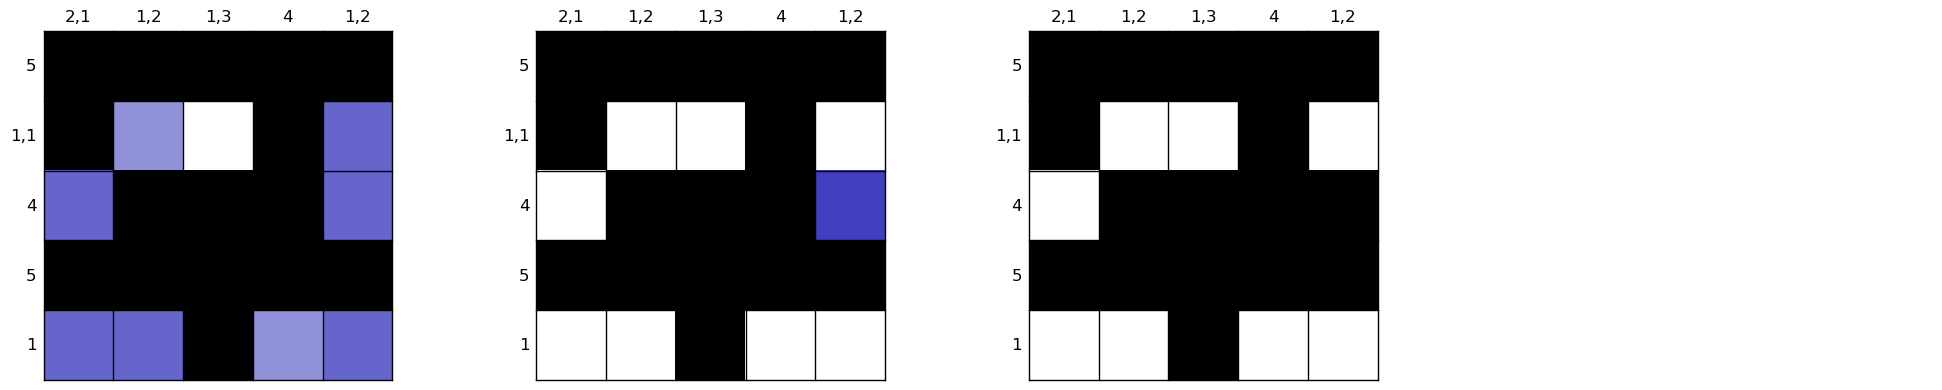

In [60]:
n = 1
pq_row = pq[n] 
target_grid = np.array(pq_row['solution'].tolist(), dtype=np.int8)
print(f"Correct solution:")
display_figure_grid([torch.tensor(target_grid)], clues=pq_row['X'], mode='raw', figsize=(5, 5))

print(f"Model predictions:")
logit_lenses = [mlp_model.forward(pq_row['X'].flatten().to(device).unsqueeze(0), layer_num=i).cpu().detach().reshape(3,5,5) for i in range(depth)]
display_figure_grid(logit_lenses, clues=(pq_row['X']), mode='blended', figsize=(20, 20))
# print(f"Intermediate solutions:")
intermediate_solutions = [torch.from_numpy(np.array(sol.tolist(), dtype=np.float32)).float() for sol in pq_row["intermediate_solutions"]]
# display_figure_grid(intermediate_solutions, clues=pq_row['X'], mode='raw', figsize=(20, 5*len(intermediate_solutions)//4 + 1), width=4)
print(f"Intermediate with Uncertainty:")
intermediate_solutions_with_uncertainty = intermediate_with_uncertainty(intermediate_solutions)
display_figure_grid(intermediate_solutions_with_uncertainty, clues=pq_row['X'], mode='normalised', figsize=(20, 5*len(intermediate_solutions_with_uncertainty)//4 + 1), width=4)


In [8]:
def test_accuracy(model, test_loader):
    """
    Evaluate the model on a test dataset and return the overall accuracy.

    Args:
        model: The neural network to evaluate.
        test_loader: DataLoader yielding (inputs, labels) batches.
        device: torch.device where the model and tensors should reside.

    Returns:
        float: Accuracy (correct / total) – 0.0 if the loader is empty.
    """
    model.eval()
    correct = 0
    total = 0
    # Custom loss – kept here in case you still want the loss value for logging
    criterion = AbstainLoss(abstain_penalty=0.7)

    with torch.no_grad():
        for inputs, labels in test_loader:
            # Move data to the proper device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Forward pass
            logits = model(inputs)          # Expected shape: [B, C, H, W] (or similar)

            # If the model output shape does not match the label shape,
            # reshape logits so that the class dimension is first.
            if logits.shape[1:] != labels.shape[1:]:
                logits = logits.view(labels.shape[0], -1, *labels.shape[1:])

            # (Optional) Compute loss per batch – useful for logging/debugging
            _ = criterion(logits, labels).item()

            filtered_logits = logits[:, :2, ...] 

            # Predicted class per spatial location (argmax over the class dimension)
            pred = filtered_logits.argmax(dim=1)    # Shape: [B, H, W]

            # Determine which samples are *fully* correct
            # `all(dim=[1,2])` checks that every pixel in a sample matches the target.
            matches = (pred == labels).all(dim=[1])

            correct += matches.sum().item()
            total   += labels.size(0)

    # Guard against division by zero
    return correct / total if total > 0 else 0.0

In [9]:
search_loader, _, search_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="requires_search == True", train_ratio=1.0)
print(f"Length of search dataset: {len(search_ds)}")
print(f"Test accuracy on search puzzles: {test_accuracy(mlp_model, search_loader):.4f}")
no_search_loader, _, no_search_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="requires_search == False", train_ratio=1.0)
print(f"Length of no-search dataset: {len(no_search_ds)}")
print(f"Test accuracy on no-search puzzles: {test_accuracy(mlp_model, no_search_loader):.4f}")

Length of search dataset: 6805
Test accuracy on search puzzles: 0.3084
Length of no-search dataset: 93195
Test accuracy on no-search puzzles: 0.9325


In [10]:
short_loader, _, short_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps < 6", train_ratio=1.0)
print(f"Length of short dataset: {len(short_ds)}")
print(f"Test accuracy on short puzzles: {test_accuracy(mlp_model, short_loader):.4f}")
long_loader, _, long_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps >= 6", train_ratio=1.0)
print(f"Length of long dataset: {len(long_ds)}")
print(f"Test accuracy on long puzzles: {test_accuracy(mlp_model, long_loader):.4f}")

Length of short dataset: 86706
Test accuracy on short puzzles: 0.9497
Length of long dataset: 13294
Test accuracy on long puzzles: 0.5013


In [11]:
sparse_loader, _, sparse_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="grid_density < 0.4", train_ratio=1.0)
print(f"Length of sparse dataset: {len(sparse_ds)}")
print(f"Test accuracy on sparse puzzles: {test_accuracy(mlp_model, sparse_loader):.4f}")
med_dense_loader, _, med_dense_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="grid_density >= 0.4 and grid_density < 0.6", train_ratio=1.0)
print(f"Length of medium dense dataset: {len(med_dense_ds)}")
print(f"Test accuracy on medium dense puzzles: {test_accuracy(mlp_model, med_dense_loader):.4f}")
dense_loader, _, dense_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="grid_density >= 0.6", train_ratio=1.0)
print(f"Length of dense dataset: {len(dense_ds)}")
print(f"Test accuracy on dense puzzles: {test_accuracy(mlp_model, dense_loader):.4f}")

Length of sparse dataset: 7966
Test accuracy on sparse puzzles: 0.6596
Length of medium dense dataset: 66547
Test accuracy on medium dense puzzles: 0.8853
Length of dense dataset: 25487
Test accuracy on dense puzzles: 0.9747


In [77]:
def query_accuracy(model, pq, query):
    loader, _, ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query=query, train_ratio=1.0)
    print(f"Length of dataset for query '{query}': {len(ds)}")
    print(f"Test accuracy on dataset for query '{query}': {test_accuracy(model, loader):.4f}")
    return test_accuracy(model, loader)

In [13]:
short_loader, _, short_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps < 6 and requires_search == True", train_ratio=1.0)
print(f"Length of short + search dataset: {len(short_ds)}")
print(f"Test accuracy on short + search puzzles: {test_accuracy(mlp_model, short_loader):.4f}")
long_loader, _, long_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps >= 6 and requires_search == True", train_ratio=1.0)
print(f"Length of long + search dataset: {len(long_ds)}")
print(f"Test accuracy on long + search puzzles: {test_accuracy(mlp_model, long_loader):.4f}")
print()


short_loader, _, short_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps < 6 and requires_search == False", train_ratio=1.0)
print(f"Length of short + non-search dataset: {len(short_ds)}")
print(f"Test accuracy on short + non-search puzzles: {test_accuracy(mlp_model, short_loader):.4f}")
long_loader, _, long_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps >= 6 and requires_search == False", train_ratio=1.0)
print(f"Length of long + non-search dataset: {len(long_ds)}")
print(f"Test accuracy on long + non-search puzzles: {test_accuracy(mlp_model, long_loader):.4f}")
print()


short_loader, _, short_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps >= 6 and requires_search == True", train_ratio=1.0)
print(f"Length of long + search dataset: {len(short_ds)}")
print(f"Test accuracy on long + search puzzles: {test_accuracy(mlp_model, short_loader):.4f}")
long_loader, _, long_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps >= 6 and requires_search == False", train_ratio=1.0)
print(f"Length of long + non-search dataset: {len(long_ds)}")
print(f"Test accuracy on long + non-search puzzles: {test_accuracy(mlp_model, long_loader):.4f}")
print()


short_loader, _, short_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps < 6 and requires_search == True", train_ratio=1.0)
print(f"Length of short + search dataset: {len(short_ds)}")
print(f"Test accuracy on short + search puzzles: {test_accuracy(mlp_model, short_loader):.4f}")
long_loader, _, long_ds, _ = pq.create_dataloaders(batch_size=200, flat=True, query="steps < 6 and requires_search == False", train_ratio=1.0)
print(f"Length of short + non-search dataset: {len(long_ds)}")
print(f"Test accuracy on short + non-search puzzles: {test_accuracy(mlp_model, long_loader):.4f}")

Length of short + search dataset: 16
Test accuracy on short + search puzzles: 0.3125
Length of long + search dataset: 6789
Test accuracy on long + search puzzles: 0.3084

Length of short + non-search dataset: 86690
Test accuracy on short + non-search puzzles: 0.9498
Length of long + non-search dataset: 6505
Test accuracy on long + non-search puzzles: 0.7025

Length of long + search dataset: 6789
Test accuracy on long + search puzzles: 0.3084
Length of long + non-search dataset: 6505
Test accuracy on long + non-search puzzles: 0.7025

Length of short + search dataset: 16
Test accuracy on short + search puzzles: 0.3125
Length of short + non-search dataset: 86690
Test accuracy on short + non-search puzzles: 0.9498


In [15]:
import torch.nn.functional as F

def grids_mse(grids1, grids2):
    full_list = []
    for grid1 in grids1:
        grid1_list = []
        for grid2 in grids2:
            grid1_list.append(F.mse_loss(grid1, grid2).item())
        full_list.append(grid1_list)
    return full_list

In [61]:
true_steps = []
model_steps = []
for n in range(2000):
    pq_row = pq[n] 
    if pq_row["steps"] != 5:
        continue

    intermediate_solutions = [torch.from_numpy(np.array(sol.tolist(), dtype=np.float32)).float() for sol in pq_row["intermediate_solutions"]]
    intermediate_solutions_with_uncertainty = intermediate_with_uncertainty(intermediate_solutions)
    normalised_step_1 = intermediate_solutions_with_uncertainty[0] / intermediate_solutions_with_uncertainty[0].sum(dim=0, keepdim=True)
    normalised_step_2 = intermediate_solutions_with_uncertainty[1] / intermediate_solutions_with_uncertainty[1].sum(dim=0, keepdim=True)
    normalised_step_3 = intermediate_solutions_with_uncertainty[2] / intermediate_solutions_with_uncertainty[2].sum(dim=0, keepdim=True)
    normalised_step_4 = intermediate_solutions_with_uncertainty[3] / intermediate_solutions_with_uncertainty[3].sum(dim=0, keepdim=True)
    normalised_step_5 = intermediate_solutions_with_uncertainty[4] / intermediate_solutions_with_uncertainty[4].sum(dim=0, keepdim=True)
    true_steps.append([normalised_step_1, normalised_step_2, normalised_step_3, normalised_step_4, normalised_step_5])


    logit_lenses = [mlp_model.forward(pq_row['X'].flatten().to(device).unsqueeze(0), layer_num=i).cpu().detach().reshape(3,5,5) for i in range(depth)]
    softmax_lenses = [torch.softmax(step, dim=0) for step in logit_lenses]
    model_steps.append(softmax_lenses)




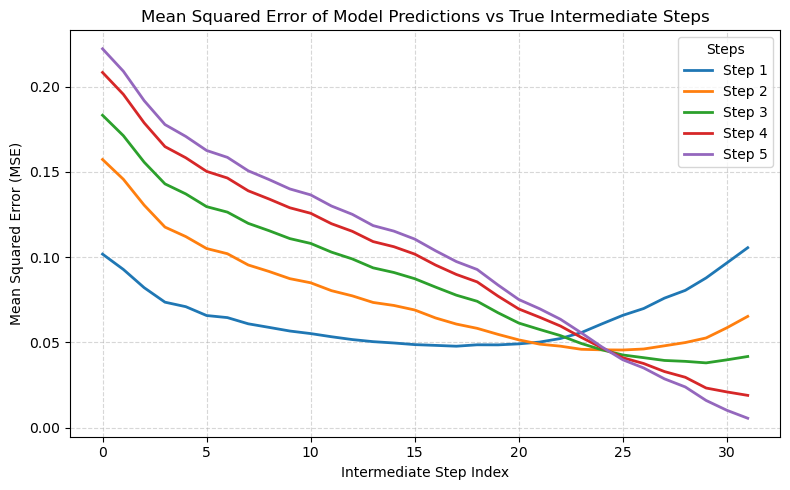

In [62]:
full_arr = []
for first_s, model_s in zip(true_steps, model_steps):
    partial_arr = np.array(grids_mse(first_s, model_s))
    full_arr.append(partial_arr)

mean_arr = np.mean(np.array(full_arr), axis=0)
arr = mean_arr

# -------------------------------------------------
# 3️⃣  Prepare the plot
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))

# Choose a colormap – you can pick any Matplotlib colormap you like
cmap = plt.get_cmap('tab10')          # good for up to ~10 distinct lines
colors = cmap(np.arange(arr.shape[0]))

# -------------------------------------------------
# 4️⃣  Plot each series
# -------------------------------------------------
for idx, (y, col) in enumerate(zip(arr, colors)):
    x = np.arange(len(y))              # x = index within inner list
    ax.plot(x, y, label=f'Step {idx+1}', color=col, linewidth=2)

# -------------------------------------------------
# 5️⃣  Polish the figure
# -------------------------------------------------
ax.set_xlabel('Intermediate Step Index')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Mean Squared Error of Model Predictions vs True Intermediate Steps')
ax.grid(True, which='both', linestyle='--', alpha=0.5)
ax.legend(title='Steps', loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
# Visualize one training prediction from c_model and compute its loss
criterion = AbstainLoss(abstain_penalty=0.7)

# Rebuild the same dataset/split used for c_model training to get a training example.
dataset = PuzzleDataset("processed/nonogram_easy_X.npy", "processed/nonogram_easy_y.npy", target_shape=(3, 5, 5))
dataset.flatten()
dataset.y = dataset.y.long()
train_dataset, test_dataset = random_split(
    dataset,
    [int(0.8 * len(dataset)), len(dataset) - int(0.8 * len(dataset))],
    generator=torch.Generator().manual_seed(42),
)
train_loader_c = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader_c = DataLoader(test_dataset, batch_size=128, shuffle=False)

batch_inputs, batch_targets = next(iter(test_loader_c))

for idx in range(1000):

    with torch.no_grad():
        logits = c_model(batch_inputs.to(device))
        if logits.shape != batch_targets.shape:
            logits = logits.reshape(batch_targets.shape[0], -1, *batch_targets.shape[1:])

    single_logits = logits[idx : idx + 1]
    single_target = batch_targets[idx : idx + 1].to(device)
    if idx >= logits.size(0) or idx >= batch_targets.size(0):
        continue

    if single_logits.numel() == 0 or single_target.numel() == 0:
        continue

    single_loss = criterion(single_logits, single_target).item()

    pred_logits_grid = single_logits[0].detach().cpu()    # [3, 5, 5]
    pred_classes = pred_logits_grid.argmax(dim=0)         # [5, 5]

    if not torch.equal(single_target[0].detach().cpu(), pred_classes):
        print(f"Input Clues:\n{batch_inputs[idx].reshape(2, 5, 3)}")
        print(f"Target (0/1):\n{single_target[0].reshape(5,5).detach().cpu()}")
        print(f"Predicted classes grid:\n{pred_classes.reshape(5, 5)}")
        print(f"Training Loss for this example: {single_loss:.4f}")
        break


NameError: name 'c_model' is not defined

In [84]:

import numpy as np
from scipy import stats
from dataclasses import dataclass
from typing import List, Dict, Tuple, Callable, Optional
import itertools

@dataclass
class FactorLevel:
    name: str
    query: str

@dataclass  
class Factor:
    name: str
    levels: List[FactorLevel]
    
    def num_levels(self):
        return len(self.levels)


def build_cell_means_data(
    factors: List[Factor],
    model,
    pq,
    query_accuracy_fn: Callable
) -> Tuple[np.ndarray, List[Dict], List[int], List[str]]:
    """
    Query accuracy for every cell in the factorial design.
    Returns cell means and metadata.
    """
    level_counts = [f.num_levels() for f in factors]
    total_cells = np.prod(level_counts)
    
    y = np.full(total_cells, np.nan)
    cell_info = []
    
    level_indices = [range(lc) for lc in level_counts]
    
    for cell_idx, level_combo in enumerate(itertools.product(*level_indices)):
        queries = []
        labels = {}
        for f_idx, level_idx in enumerate(level_combo):
            factor = factors[f_idx]
            level = factor.levels[level_idx]
            queries.append(f"({level.query})")
            labels[factor.name] = level.name
        
        cell_query = " and ".join(queries)
        
        # Query accuracy - handle any return type robustly
        try:
            acc = query_accuracy_fn(model, pq, cell_query)
            # Convert to float, handling tensors, numpy scalars, etc.
            if hasattr(acc, 'item'):  # PyTorch tensor, numpy scalar
                acc = float(acc.item())
            else:
                acc = float(acc)
            
            if np.isnan(acc) or np.isinf(acc):
                acc = np.nan
        except Exception as e:
            acc = np.nan
        
        y[cell_idx] = acc
        cell_info.append({
            'cell_idx': cell_idx,
            'query': cell_query,
            'labels': labels,
            'accuracy': acc,
            'level_combo': level_combo,
            'n_factors': len(factors)
        })
    
    return y, cell_info, level_counts, [f.name for f in factors]


def build_design_matrix_effects_coding(
    cell_info: List[Dict],
    level_counts: List[int],
    factor_names: List[str]
) -> np.ndarray:
    """
    Build design matrix using effects coding (sum-to-zero contrasts).
    This avoids the singularity of one-hot coding.
    
    Model: y = intercept + sum over factors of (effect contrasts)
    
    For a factor with k levels, we use k-1 contrast columns.
    The omitted level's effect is -sum of the others (sum-to-zero constraint).
    """
    n_cells = len(cell_info)
    n_factors = len(level_counts)
    
    # Total params: 1 intercept + sum(k_i - 1) for each factor
    n_params = 1 + sum(k - 1 for k in level_counts)
    X = np.zeros((n_cells, n_params))
    X[:, 0] = 1  # Intercept column
    
    col_idx = 1
    for f_idx in range(n_factors):
        k = level_counts[f_idx]
        # For each level except the last (reference), create a contrast column
        for level_idx in range(k - 1):
            for cell_idx, cell in enumerate(cell_info):
                cell_level = cell['level_combo'][f_idx]
                if cell_level == level_idx:
                    X[cell_idx, col_idx] = 1
                elif cell_level == k - 1:
                    X[cell_idx, col_idx] = -1  # reference level gets -1
                # else 0
            col_idx += 1
    
    return X


def fit_anova_model(
    y: np.ndarray,
    X: np.ndarray,
    factor_names: List[str],
    level_counts: List[int],
    cell_info: List[Dict]
) -> Dict:
    """
    Fit GLM with effects coding and compute Type III SS.
    """
    valid_mask = ~np.isnan(y)
    y_valid = y[valid_mask]
    X_valid = X[valid_mask]
    n_obs = len(y_valid)
    n_params = X_valid.shape[1]
    
    if n_obs < n_params:
        raise ValueError(
            f"Not enough observations ({n_obs}) for parameters ({n_params}). "
            f"Need at least {n_params} cells with data."
        )
    
    # Fit via least squares
    beta, residuals, rank, s = np.linalg.lstsq(X_valid, y_valid, rcond=None)
    
    if rank < n_params:
        print(f"WARNING: Design matrix is rank-deficient (rank={rank}, params={n_params}).")
        print("Some factors may be perfectly correlated.")
    
    y_pred = X_valid @ beta
    residuals = y_valid - y_pred
    
    ss_total = np.sum((y_valid - np.mean(y_valid)) ** 2)
    ss_residual = np.sum(residuals ** 2)
    df_residual = n_obs - rank
    mse = ss_residual / df_residual if df_residual > 0 else np.inf
    
    r_squared = 1 - ss_residual / ss_total if ss_total > 0 else 0
    adj_r_squared = 1 - (1 - r_squared) * (n_obs - 1) / df_residual if df_residual > 0 else 0
    
    # Standard errors
    try:
        cov_beta = mse * np.linalg.inv(X_valid.T @ X_valid)
        se_beta = np.sqrt(np.diag(cov_beta))
    except np.linalg.LinAlgError:
        cov_beta = mse * np.linalg.pinv(X_valid.T @ X_valid)
        se_beta = np.sqrt(np.diag(cov_beta))
    
    t_stats = beta / (se_beta + 1e-12)
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df_residual))
    
    # === TYPE III SUMS OF SQUARES ===
    # Test each factor by comparing full model vs model without that factor
    type3_results = []
    param_idx = 1  # skip intercept
    
    for f_idx, fname in enumerate(factor_names):
        k = level_counts[f_idx]
        df_factor = k - 1
        
        # Columns to drop: the contrast columns for this factor
        drop_cols = list(range(param_idx, param_idx + df_factor))
        param_idx += df_factor
        
        keep_cols = [i for i in range(X_valid.shape[1]) if i not in drop_cols]
        X_reduced = X_valid[:, keep_cols]
        
        beta_reduced, _, rank_reduced, _ = np.linalg.lstsq(X_reduced, y_valid, rcond=None)
        y_pred_reduced = X_reduced @ beta_reduced
        ss_reduced = np.sum((y_valid - y_pred_reduced) ** 2)
        
        ss_factor = ss_reduced - ss_residual
        ms_factor = ss_factor / df_factor if df_factor > 0 else 0
        f_stat = ms_factor / mse if mse > 0 else 0
        p_factor = 1 - stats.f.cdf(f_stat, df_factor, df_residual) if df_factor > 0 else 1.0
        
        type3_results.append({
            'factor': fname,
            'ss': ss_factor,
            'df': df_factor,
            'ms': ms_factor,
            'f': f_stat,
            'p': p_factor,
            'eta_sq': ss_factor / ss_total if ss_total > 0 else 0,
            'significant': p_factor < 0.05,
            'param_cols': drop_cols
        })
    
    # === ADJUSTED MARGINAL MEANS (EMMs) ===
    # For each factor level, compute the mean prediction when that level is
    # held constant and all other factors are averaged over (marginalized)
    
    emm_results = {}
    param_idx = 1
    
    for f_idx, fname in enumerate(factor_names):
        k = level_counts[f_idx]
        df_factor = k - 1
        factor_params = list(range(param_idx, param_idx + df_factor))
        
        level_emms = []
        for level_idx in range(k):
            # Build a contrast vector for this level
            # intercept + effect for this level (or -sum for reference)
            contrast = np.zeros(n_params)
            contrast[0] = 1  # intercept
            
            if level_idx < k - 1:
                # This level has its own contrast column
                contrast[factor_params[level_idx]] = 1
            else:
                # Reference level: effect = -sum of other contrasts
                for fp in factor_params:
                    contrast[fp] = -1
            
            emm_mean = contrast @ beta
            emm_se = np.sqrt(contrast @ cov_beta @ contrast)
            
            level_emms.append({
                'level': factors[f_idx].levels[level_idx].name,
                'level_idx': level_idx,
                'emm': emm_mean,
                'se': emm_se,
                'ci_lower': emm_mean - 1.96 * emm_se,
                'ci_upper': emm_mean + 1.96 * emm_se
            })
        
        emm_results[fname] = level_emms
        param_idx += df_factor
    
    # === PAIRWISE COMPARISONS (Tukey HSD) ===
    pairwise_results = {}
    
    for fname, level_emms in emm_results.items():
        k = len(level_emms)
        comparisons = []
        
        for i in range(k):
            for j in range(i + 1, k):
                diff = level_emms[i]['emm'] - level_emms[j]['emm']
                # Build contrast for difference
                c = np.zeros(n_params)
                c[0] = 0  # intercept cancels
                
                # Find the factor's parameter block
                p_idx = 1
                for fi, fn in enumerate(factor_names):
                    if fn == fname:
                        ki = level_counts[fi]
                        fps = list(range(p_idx, p_idx + ki - 1))
                        
                        if level_emms[i]['level_idx'] < ki - 1:
                            c[fps[level_emms[i]['level_idx']]] += 1
                        else:
                            for fp in fps:
                                c[fp] -= 1
                        
                        if level_emms[j]['level_idx'] < ki - 1:
                            c[fps[level_emms[j]['level_idx']]] -= 1
                        else:
                            for fp in fps:
                                c[fp] += 1
                        break
                    p_idx += level_counts[fi] - 1
                
                se_diff = np.sqrt(c @ cov_beta @ c)
                t_val = diff / (se_diff + 1e-12)
                p_uncorrected = 2 * (1 - stats.t.cdf(abs(t_val), df_residual))
                
                # Tukey HSD critical value
                try:
                    q_crit = stats.studentized_range.ppf(0.95, k, df_residual)
                    margin = q_crit * np.sqrt(mse / 2)
                except:
                    margin = np.inf
                
                comparisons.append({
                    'level_a': level_emms[i]['level'],
                    'level_b': level_emms[j]['level'],
                    'difference': diff,
                    'se': se_diff,
                    't': t_val,
                    'p_uncorrected': p_uncorrected,
                    'significant_uncorrected': p_uncorrected < 0.05,
                    'significant_tukey': abs(diff) > margin
                })
        
        pairwise_results[fname] = comparisons
    
    return {
        'coefficients': beta.tolist(),
        'se': se_beta.tolist(),
        't_stats': t_stats.tolist(),
        'p_values': p_values.tolist(),
        'r_squared': r_squared,
        'adj_r_squared': adj_r_squared,
        'mse': mse,
        'df_residual': df_residual,
        'n_obs': n_obs,
        'n_params': rank,
        'type3': type3_results,
        'emm': emm_results,
        'pairwise': pairwise_results,
        'y': y_valid.tolist(),
        'y_pred': y_pred.tolist(),
        'cell_info': [cell_info[i] for i in range(len(cell_info)) if valid_mask[i]]
    }


# ============================================================================
# MAIN ANALYSIS FUNCTION
# ============================================================================

def run_factorial_analysis(
    factors: List[Factor],
    model,
    pq,
    query_accuracy_fn: Callable,
    verbose: bool = True
) -> Dict:
    """
    Main entry point. Runs the full factorial ANOVA analysis.
    """
    if verbose:
        print("=" * 70)
        print(f"FACTORIAL ANOVA: {' + '.join(f.name for f in factors)}")
        print("=" * 70)
        level_counts = [f.num_levels() for f in factors]
        total_cells = np.prod(level_counts)
        print(f"Design: {' × '.join(str(lc) for lc in level_counts)} = {total_cells} cells")
        for f in factors:
            print(f"  {f.name}: {', '.join(l.name for l in f.levels)}")
        print()
    
    # Step 1: Get cell means
    y, cell_info, level_counts, factor_names = build_cell_means_data(
        factors, model, pq, query_accuracy_fn
    )
    
    n_valid = np.sum(~np.isnan(y))
    n_total = len(y)
    
    if verbose:
        print(f"Valid cells with data: {n_valid}/{n_total}")
        print()
    
    if n_valid == 0:
        raise ValueError("No valid observations found. Check your query_accuracy function.")
    
    # Step 2: Build design matrix with effects coding
    X = build_design_matrix_effects_coding(cell_info, level_counts, factor_names)
    
    n_params = X.shape[1]
    if verbose:
        print(f"Model parameters: {n_params} (1 intercept + {n_params - 1} effect contrasts)")
        print(f"Observations: {n_valid}")
        print()
    
    if n_valid < n_params:
        raise ValueError(
            f"Not enough observations ({n_valid}) for parameters ({n_params}). "
            f"Need at least {n_params} cells with data. Consider merging levels or removing factors."
        )
    
    # Step 3: Fit model
    results = fit_anova_model(y, X, factor_names, level_counts, cell_info)
    
    # Step 4: Print results
    if verbose:
        print(f"Model Fit: R² = {results['r_squared']:.4f}, adj-R² = {results['adj_r_squared']:.4f}")
        print(f"Residual MSE = {results['mse']:.6f}, df = {results['df_residual']}")
        print()
        
        print("-" * 70)
        print("TYPE III SUMS OF SQUARES (Effect after controlling for all others)")
        print("-" * 70)
        print(f"{'Factor':<15} {'SS':>10} {'df':>4} {'MS':>10} {'F':>10} {'p':>10} {'η²':>8} {'Sig'}")
        print("-" * 70)
        for r in results['type3']:
            sig = "***" if r['p'] < 0.001 else "**" if r['p'] < 0.01 else "*" if r['p'] < 0.05 else ""
            print(f"{r['factor']:<15} {r['ss']:>10.4f} {r['df']:>4} {r['ms']:>10.4f} {r['f']:>10.3f} {r['p']:>10.6f} {r['eta_sq']:>8.4f} {sig}")
        print()
        
        print("-" * 70)
        print("ADJUSTED MARGINAL MEANS (EMMs)")
        print("-" * 70)
        print("Fair comparison: each level adjusted to common values of other factors")
        print()
        for fname, levels in results['emm'].items():
            print(f"  {fname}:")
            for lvl in levels:
                print(f"    {lvl['level']:<18} EMM = {lvl['emm']:.4f}  [CI: {lvl['ci_lower']:.4f}, {lvl['ci_upper']:.4f}]")
            print()
        
        print("-" * 70)
        print("PAIRWISE COMPARISONS (Tukey HSD)")
        print("-" * 70)
        for fname, comps in results['pairwise'].items():
            print(f"\n  {fname}:")
            for c in comps:
                sig = " ***" if c['significant_tukey'] else " *" if c['significant_uncorrected'] else ""
                print(f"    {c['level_a']:<12} vs {c['level_b']:<12}: diff = {c['difference']:+.4f}  "
                      f"p = {c['p_uncorrected']:.4f}{sig}")
        print()
    
    return results


# ============================================================================
# DEFINE YOUR FACTORS
# ============================================================================

density = Factor("density", [
    FactorLevel("sparse", "grid_density < 0.4"),
    FactorLevel("medium", "grid_density >= 0.4 and grid_density < 0.6"),
    FactorLevel("dense", "grid_density >= 0.6"),
])

steps = Factor("steps", [
    FactorLevel("lt3", "steps < 3"),
    FactorLevel("eq3", "steps == 3"),
    FactorLevel("eq4", "steps == 4"),
    FactorLevel("eq5", "steps == 5"),
    FactorLevel("eq6", "steps == 6"),
    FactorLevel("gt6", "steps > 6"),
])

search = Factor("search", [
    FactorLevel("requires_search", "requires_search == True"),
    FactorLevel("no_search", "requires_search == False"),
])

# Store globally for EMM computation
factors = [density, steps, search]

print("Factors defined successfully!")
print(f"Density: {density.num_levels()} levels")
print(f"Steps: {steps.num_levels()} levels")
print(f"Search: {search.num_levels()} levels")


Factors defined successfully!
Density: 3 levels
Steps: 6 levels
Search: 2 levels


In [88]:
results = run_factorial_analysis(factors, mlp_model, pq, query_accuracy)
print(results)

FACTORIAL ANOVA: density + steps + search
Design: 3 × 6 × 2 = 36 cells
  density: sparse, medium, dense
  steps: lt3, eq3, eq4, eq5, eq6, gt6
  search: requires_search, no_search

Length of dataset for query '(grid_density < 0.4) and (steps < 3) and (requires_search == False)': 549
Test accuracy on dataset for query '(grid_density < 0.4) and (steps < 3) and (requires_search == False)': 0.9909
Length of dataset for query '(grid_density < 0.4) and (steps == 3) and (requires_search == False)': 1915
Test accuracy on dataset for query '(grid_density < 0.4) and (steps == 3) and (requires_search == False)': 0.9546
Length of dataset for query '(grid_density < 0.4) and (steps == 4) and (requires_search == False)': 1482
Test accuracy on dataset for query '(grid_density < 0.4) and (steps == 4) and (requires_search == False)': 0.9028
Length of dataset for query '(grid_density < 0.4) and (steps == 5) and (requires_search == True)': 13
Test accuracy on dataset for query '(grid_density < 0.4) and (st